<a href="https://colab.research.google.com/github/Ubaidrees/Health-Risk-Classification-124/blob/main/Health_Risk_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Project Name: Health Risk Classification (Pima Indians Diabetes)
#Name: Ubaid Idrees
#Roll No: 124

In [ ]:
#importing librarues
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

# Quick look at the first few rows
print("--- First 5 Rows ---")
display(df.head())

# Check data types and basic info
print("\n--- Dataset Info ---")
df.info()

# Checking for any missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- First 5 Rows ---


,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   6       767 non-null    int64  
 1   148     767 non-null    int64  
 2   72      767 non-null    int64  
 3   35      767 non-null    int64  
 4   0       767 non-null    int64  
 5   33.6    767 non-null    float64
 6   0.627   767 non-null    float64
 7   50      767 non-null    int64  
 8   1       767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

--- Missing Values ---
6        0
148      0
72       0
35       0
0        0
33.6     0
0.627    0
50       0
1        0
dtype: int64


In [16]:
# Define column names for the Pima Indians Diabetes dataset
column_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

# Reload the dataset with proper column names
df = pd.read_csv('diabetes.csv', names=column_names)

# Check the first 5 rows again with correct headers
print("--- Dataset with Proper Column Names ---")
display(df.head())

--- Dataset with Proper Column Names ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
# Separate features and target variable
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (614, 8)
Testing data shape: (154, 8)


In [19]:
# Scale the features so all values are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVC model
svc_model = SVC(random_state=42)
svc_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = svc_model.predict(X_test_scaled)

# Evaluate the model
print("--- SVC Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

--- SVC Model Results ---
Accuracy: 73.38%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



In [20]:
# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree model
print("--- Decision Tree Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

--- Decision Tree Model Results ---
Accuracy: 74.68%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



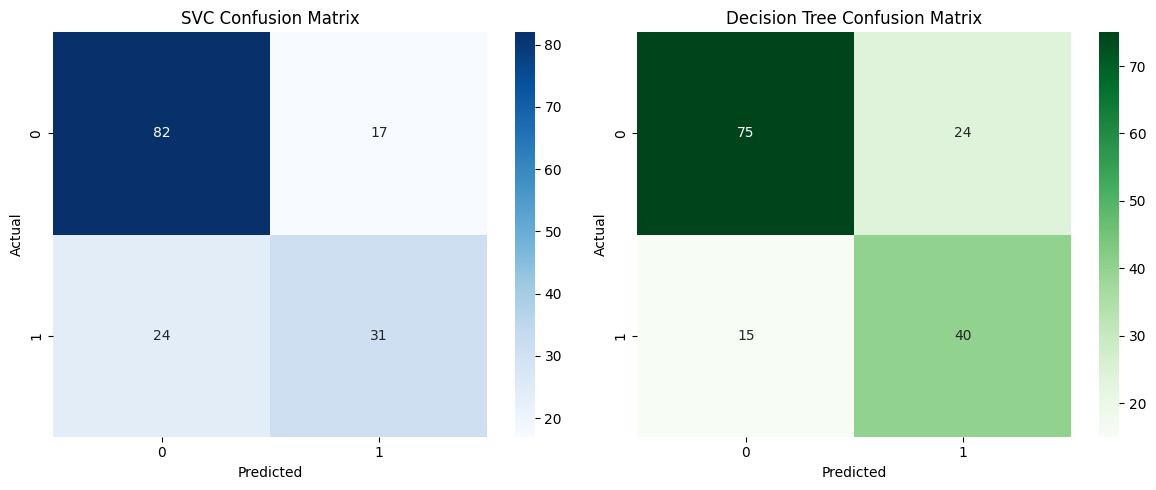

In [21]:
# Confusion Matrix for both models
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SVC Confusion Matrix
cm_svc = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('SVC Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()